In [146]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
import numpy as np 
import pandas as pd 
%matplotlib inline 

In [147]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [148]:
x,y

(array([[  2.87859266,  -2.79859489],
        [  1.07554212, -10.48077747],
        [  4.38081377,   0.01936636],
        ...,
        [  1.27390007, -11.72293355],
        [  0.73037988, -10.43751423],
        [  4.95413506,  -0.69624613]], shape=(1000, 2)),
 array([2, 1, 2, 0, 2, 0, 1, 0, 1, 0, 2, 1, 2, 1, 2, 0, 1, 1, 0, 2, 1, 0,
        2, 0, 2, 2, 0, 1, 2, 0, 2, 0, 0, 0, 2, 2, 0, 1, 2, 1, 1, 1, 2, 2,
        2, 2, 1, 1, 0, 0, 2, 1, 1, 2, 1, 0, 0, 0, 1, 0, 1, 2, 1, 0, 2, 0,
        2, 0, 1, 1, 0, 1, 2, 1, 1, 0, 0, 0, 1, 0, 2, 1, 1, 1, 2, 1, 2, 2,
        1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 2, 1, 1, 1, 2, 1, 0, 0, 2,
        2, 1, 2, 1, 2, 0, 1, 2, 0, 0, 1, 2, 0, 2, 1, 1, 0, 1, 0, 0, 1, 1,
        0, 0, 1, 0, 2, 1, 1, 0, 2, 0, 0, 1, 1, 2, 2, 2, 2, 2, 1, 2, 0, 1,
        1, 2, 0, 2, 1, 0, 1, 2, 2, 2, 2, 1, 2, 2, 0, 0, 0, 1, 0, 1, 1, 2,
        2, 0, 2, 0, 2, 0, 2, 1, 2, 1, 1, 2, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
        2, 0, 0, 2, 0, 2, 1, 1, 1, 2, 2, 2, 1, 2, 1, 2, 1, 0, 0, 1, 0, 0,


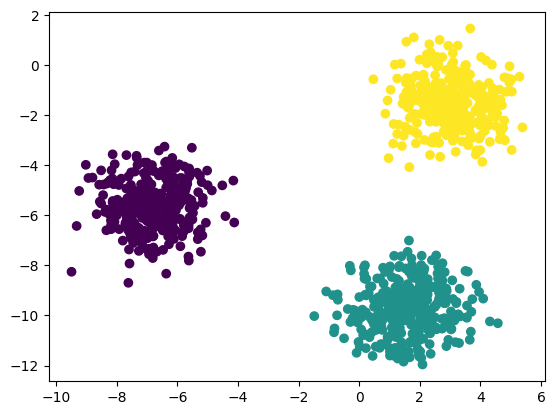

In [149]:
plt.scatter(x[:,0],x[:,1],c=y)

In [150]:
#std FEATURE SCALING 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split 
scaler=StandardScaler()

In [151]:
xtr,xte,ytr,yte=train_test_split(x,y,test_size=0.33,random_state=42)

In [152]:
xtr_scaled=scaler.fit_transform(xtr)
xte_scaled=scaler.transform(xte)

In [153]:
from sklearn.cluster import KMeans

### ELBOW METHOD

In [154]:
wcss=[]
for k in range(1,11):
    km=KMeans(n_clusters=k,init="k-means++")
    km.fit(xtr_scaled)
    wcss.append(km.inertia_)

In [155]:
wcss

[1340.0000000000007,
 648.5834964763897,
 85.2709666361757,
 71.97225260143406,
 61.09842084795892,
 57.556300006024976,
 46.33854810952562,
 41.09602674424599,
 37.601434006359725,
 34.29657084482195]

Text(0, 0.5, 'wcss')

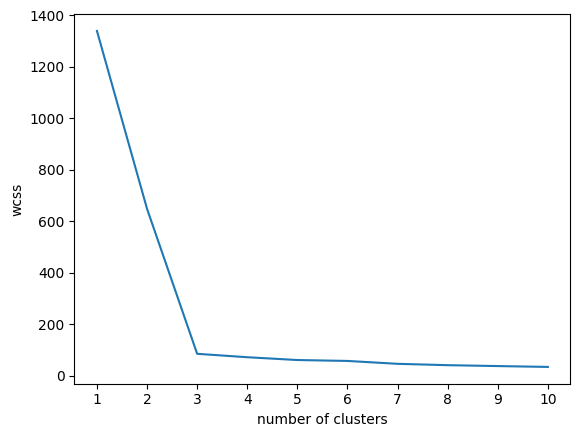

In [156]:
## plot elboe curve 
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("wcss")

In [157]:
wcss[2]

85.2709666361757

In [158]:
km=KMeans(n_clusters=k,init="k-means++")

In [159]:
km.fit_predict(xtr_scaled)
y_pred=km.predict(xte_scaled)

In [160]:
y_pred

array([8, 9, 8, 9, 2, 8, 3, 5, 6, 7, 9, 2, 2, 5, 8, 8, 7, 9, 2, 7, 2, 5,
       2, 2, 9, 1, 1, 2, 0, 9, 8, 8, 5, 5, 9, 7, 6, 0, 6, 8, 0, 0, 0, 5,
       7, 9, 4, 9, 9, 6, 4, 5, 0, 8, 8, 6, 1, 6, 7, 7, 7, 5, 2, 6, 3, 9,
       2, 9, 2, 2, 2, 3, 1, 0, 1, 7, 7, 9, 9, 7, 1, 6, 0, 8, 4, 0, 0, 6,
       7, 8, 9, 1, 9, 8, 6, 2, 7, 3, 2, 8, 8, 2, 8, 1, 1, 9, 8, 7, 8, 0,
       4, 8, 2, 2, 7, 7, 7, 5, 8, 2, 1, 0, 8, 0, 2, 2, 6, 0, 3, 5, 9, 7,
       7, 6, 2, 2, 5, 2, 7, 6, 7, 2, 6, 8, 8, 4, 7, 8, 8, 4, 8, 4, 0, 8,
       7, 9, 9, 9, 5, 3, 7, 2, 6, 6, 7, 1, 6, 8, 7, 4, 2, 8, 6, 3, 0, 6,
       2, 2, 2, 6, 3, 2, 2, 8, 2, 4, 3, 2, 2, 7, 7, 7, 8, 8, 6, 2, 5, 7,
       6, 9, 2, 8, 8, 1, 2, 9, 9, 6, 9, 3, 8, 2, 1, 8, 7, 7, 9, 0, 7, 9,
       8, 7, 7, 2, 1, 6, 7, 2, 9, 8, 6, 7, 0, 0, 2, 8, 8, 2, 3, 7, 2, 5,
       8, 6, 7, 7, 8, 8, 1, 8, 9, 3, 8, 0, 8, 7, 6, 6, 0, 2, 5, 1, 8, 1,
       1, 2, 2, 2, 8, 9, 2, 2, 0, 5, 6, 8, 0, 2, 3, 8, 7, 2, 9, 7, 1, 9,
       7, 2, 2, 2, 8, 6, 8, 7, 2, 8, 7, 1, 8, 1, 5,

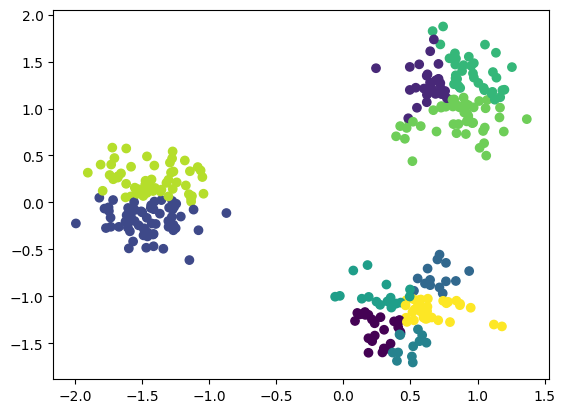

In [161]:
plt.scatter(xte_scaled[:,0],xte_scaled[:,1],c=y_pred)

## validating the k value 
1) knee locator
2) silhoute scoring

In [163]:
from kneed import KneeLocator

In [164]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [165]:
kl.elbow

np.int64(3)

In [166]:
## silhoute scoring 

from sklearn.metrics import silhouette_score

In [167]:
silhoute_coeffff=[]

for k in range(2,11):
    km=KMeans(n_clusters=k,init='k-means++')
    km.fit(xtr_scaled)
    score=silhouette_score(xtr_scaled,km.labels_)
    silhoute_coeffff.append(score)

In [168]:
silhoute_coeffff

[0.5398085317491257,
 0.7993239152670755,
 0.6427148843044626,
 0.48848945074725464,
 0.34362726991470405,
 0.35080579591744204,
 0.35076038792455677,
 0.34889885582717844,
 0.34363415134857506]

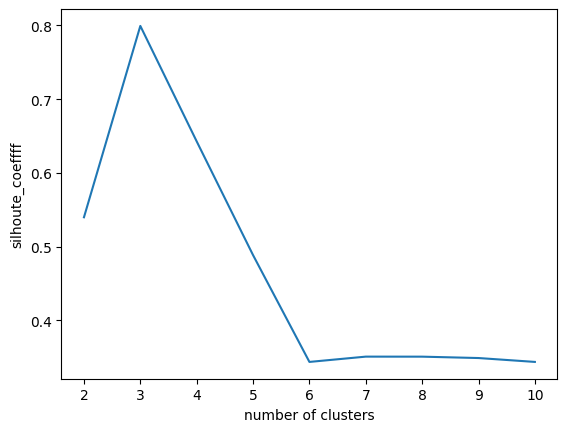

In [169]:
## plot elboe curve 
plt.plot(range(2,11),silhoute_coeffff)
plt.xticks(range(2,11))
plt.xlabel("number of clusters")
plt.ylabel("silhoute_coeffff")
plt.show()